In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import lightgbm as lgb

from sklearn.svm import SVC
from xgboost import XGBClassifier 
from catboost import CatBoostClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, StackingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv('/kaggle/input/datasets/laotse/credit-risk-dataset/credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [5]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [6]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(165)

In [8]:
info_df = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Missing %": (df.isnull().sum()/len(df) * 100).round(2),
    "Unique Values": df.nunique(),
    "Unique Category": [df[col].unique() for col in df.columns],
})

info_df

,Data Type,Missing Values,Missing %,Unique Values,Unique Category
person_age,int64,0,0.00,58,"[22, 21, 25, 23, 24, 26, 144, 123, 20, 32, 34,..."
person_income,int64,0,0.00,4295,"[59000, 9600, 65500, 54400, 9900, 77100, 78956..."
person_home_ownership,object,0,0.00,4,"[RENT, OWN, MORTGAGE, OTHER]"
person_emp_length,float64,895,2.75,36,"[123.0, 5.0, 1.0, 4.0, 8.0, 2.0, 6.0, 7.0, 0.0..."
loan_intent,object,0,0.00,6,"[PERSONAL, EDUCATION, MEDICAL, VENTURE, HOMEIM..."
loan_grade,object,0,0.00,7,"[D, B, C, A, E, F, G]"
loan_amnt,int64,0,0.00,753,"[35000, 1000, 5500, 2500, 1600, 4500, 30000, 1..."
loan_int_rate,float64,3116,9.56,348,"[16.02, 11.14, 12.87, 15.23, 14.27, 7.14, 12.4..."
loan_status,int64,0,0.00,2,"[1, 0]"
loan_percent_income,float64,0,0.00,77,"[0.59, 0.1, 0.57, 0.53, 0.55, 0.25, 0.45, 0.44..."


In [9]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
person_age,1.000000,0.173202,0.163106,0.050787,0.012580,-0.021629,-0.042411,0.859133
person_income,0.173202,1.000000,0.134268,0.266820,0.000792,-0.144449,-0.254471,0.117987
person_emp_length,0.163106,0.134268,1.000000,0.113082,-0.056405,-0.082489,-0.054111,0.144699
loan_amnt,0.050787,0.266820,0.113082,1.000000,0.146813,0.105376,0.572612,0.041967
loan_int_rate,0.012580,0.000792,-0.056405,0.146813,1.000000,0.335133,0.120314,0.016696
loan_status,-0.021629,-0.144449,-0.082489,0.105376,0.335133,1.000000,0.379366,-0.015529
loan_percent_income,-0.042411,-0.254471,-0.054111,0.572612,0.120314,0.379366,1.000000,-0.031690
cb_person_cred_hist_length,0.859133,0.117987,0.144699,0.041967,0.016696,-0.015529,-0.031690,1.000000


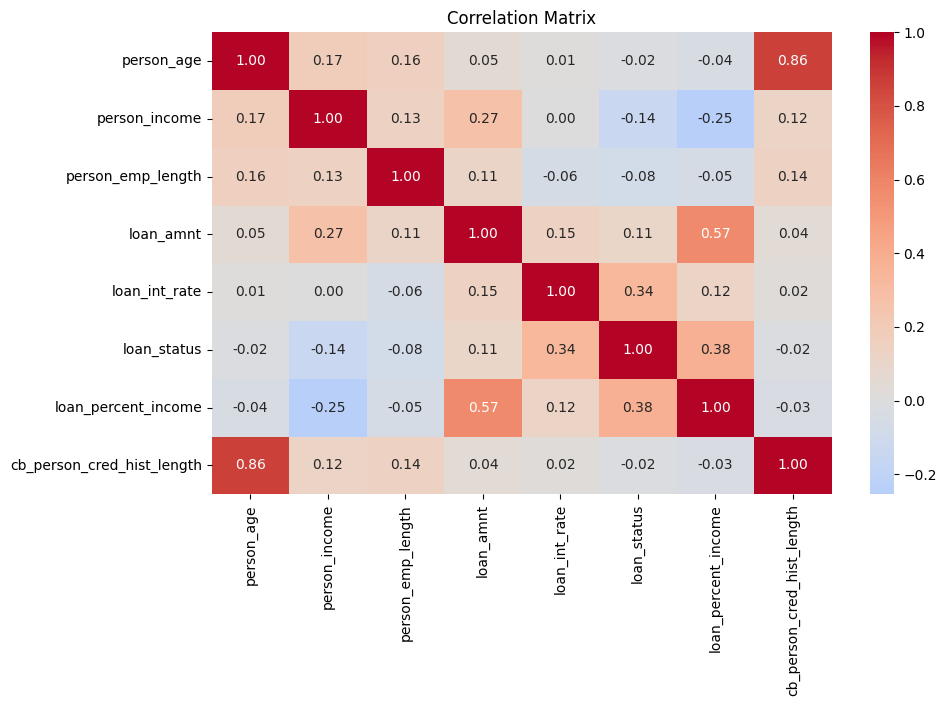

In [10]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

## Target Variable Distribution

In [11]:
loan_dist = df['loan_status'].value_counts()
loan_pct = df['loan_status'].value_counts(normalize=True) * 100

print("Loan Distribution:\n")
print(f"  Non-default:  {loan_dist[0]} ({loan_pct[0]:.2f}%)")  # 0 — кредит возвращен (Non-default)
print(f"  Default:      {loan_dist[1]}  ({loan_pct[1]:.2f}%)") # 1 — кредит не возвращен (Default)


Loan Distribution:

  Non-default:  25473 (78.18%)
  Default:      7108  (21.82%)


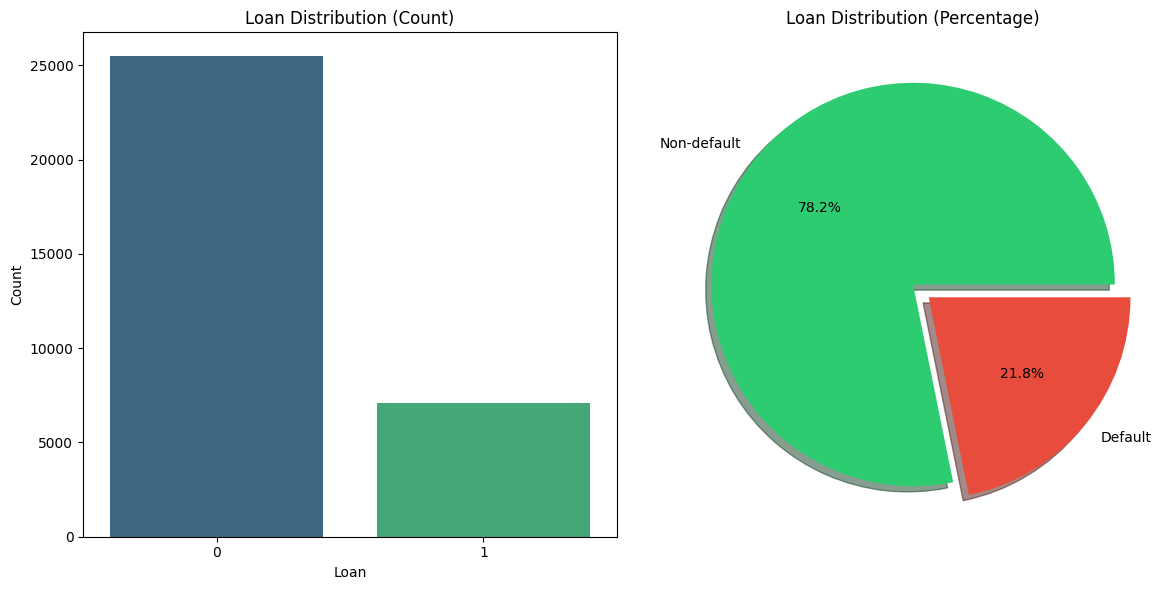

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.countplot(data=df, x='loan_status', hue='loan_status', legend=False, palette='viridis', ax=ax[0])
ax[0].set_title('Loan Distribution (Count)', fontsize=12)
ax[0].set_xlabel('Loan')
ax[0].set_ylabel('Count')

colors = ['#2ecc71', '#e74c3c']
ax[1].pie(loan_dist, labels=['Non-default', 'Default'], autopct='%1.1f%%',
          colors=colors, explode=(0, 0.1), shadow=True)
ax[1].set_title('Loan Distribution (Percentage)', fontsize=12)

plt.tight_layout()
plt.show()


## Features Distribution

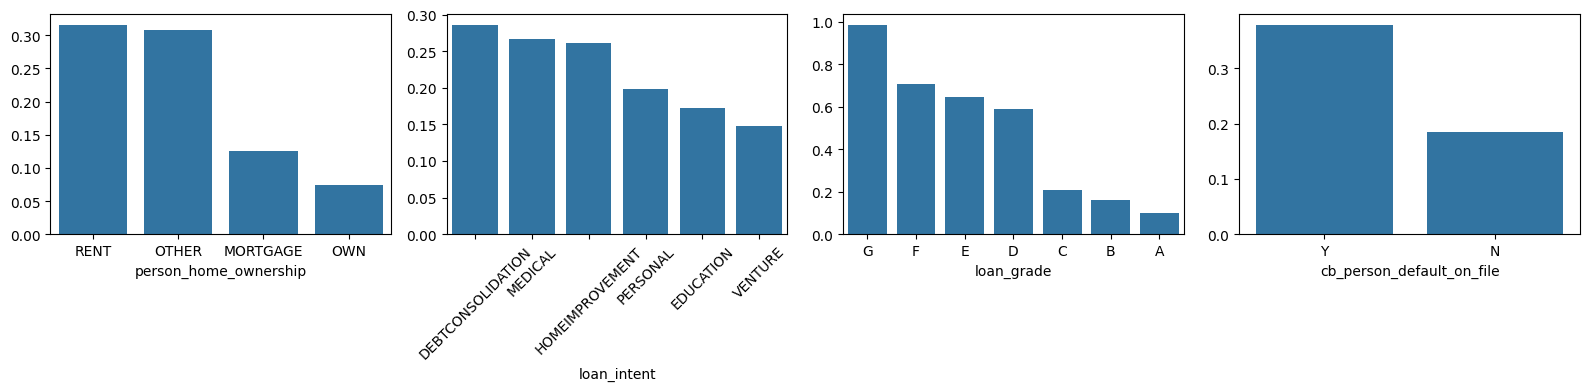

In [13]:
cat_features = df.select_dtypes(include=['object']).columns.tolist()

fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for idx, col in enumerate(cat_features):
    default_rate = df.groupby(col)['loan_status'].mean().sort_values(ascending=False)
    sns.barplot(x=default_rate.index, y=default_rate.values, ax=axes[idx])

    if idx==1:
        axes[idx].tick_params(axis='x', rotation=45)
        
for idx in range(len(cat_features), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

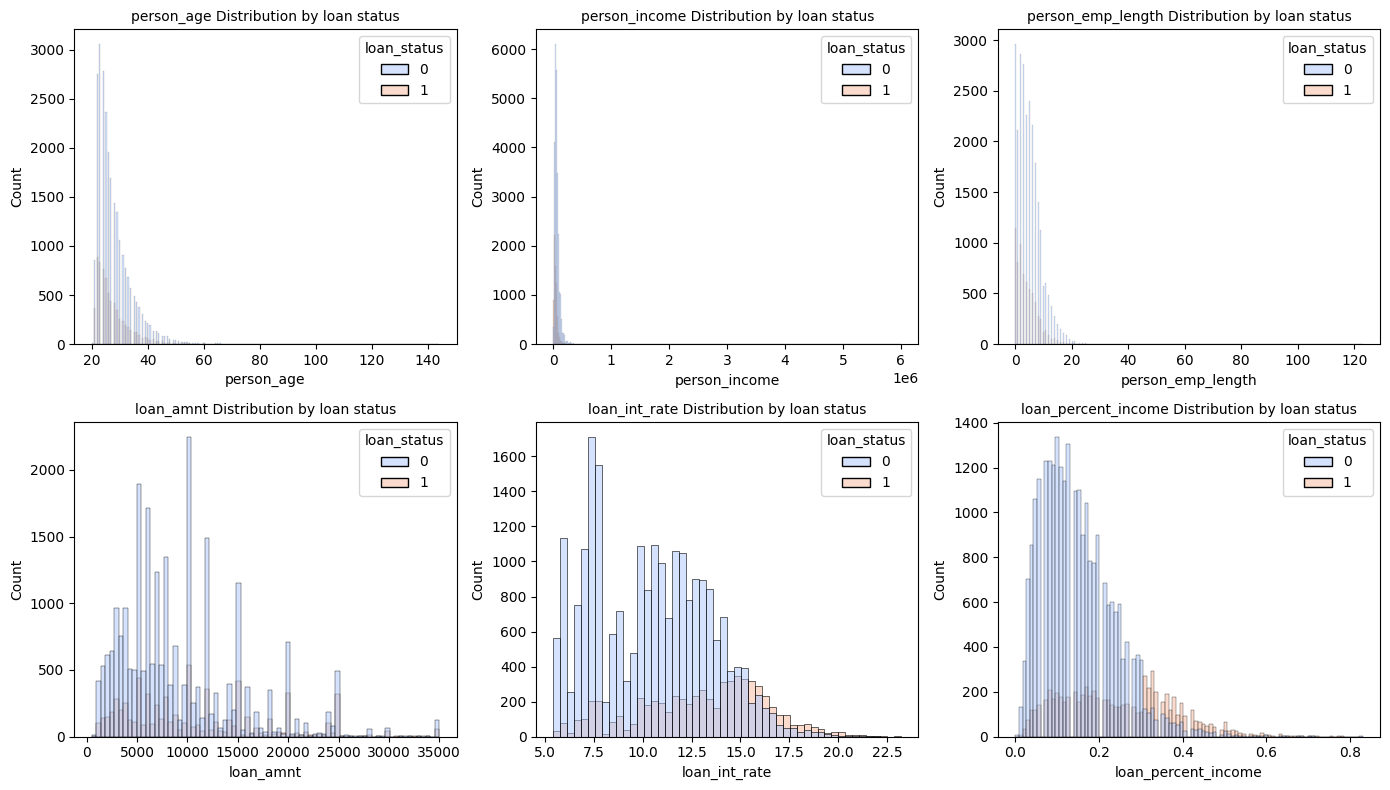

In [14]:
numerical = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, col in enumerate(numerical):
    if idx < 6:
        sns.histplot(data=df, x=col, hue='loan_status', ax=axes[idx], palette='coolwarm')
        axes[idx].set_title(f'{col} Distribution by loan status', fontsize=10)

plt.tight_layout()
plt.show()

In [15]:
df.drop_duplicates(inplace=True)
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              887
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3095
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

## Split Data into Train Test

In [16]:
X = df.drop(['loan_status'], axis=1)
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, stratify=y, random_state=42
)

## Data Preprocessing

In [17]:
num_cols = [
    'person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'
]

cat_cols = [
    'person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file'
]

num_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('imputer', KNNImputer(n_neighbors=5))
])

cat_pipeline = Pipeline([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols),
    ]
)

preprocessor.set_output(transform="pandas")

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [18]:
X_train_processed.head()

,num__person_age,num__person_income,num__person_emp_length,num__loan_amnt,num__loan_int_rate,num__loan_percent_income,num__cb_person_cred_hist_length,cat__person_home_ownership_MORTGAGE,cat__person_home_ownership_OTHER,cat__person_home_ownership_OWN,...,cat__loan_intent_VENTURE,cat__loan_grade_A,cat__loan_grade_B,cat__loan_grade_C,cat__loan_grade_D,cat__loan_grade_E,cat__loan_grade_F,cat__loan_grade_G,cat__cb_person_default_on_file_N,cat__cb_person_default_on_file_Y
7173,-0.743283,0.158047,-1.149310,-0.412319,-1.385966,-0.756336,-0.938859,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
16396,-0.428746,-0.061331,1.019468,2.450820,0.528159,2.147007,-0.444484,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
21744,0.514864,-0.201936,-1.149310,-0.571382,-1.385966,-0.569023,0.791454,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
27805,-0.114209,2.570406,1.742394,-0.571382,-1.200429,-1.318273,0.049891,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
24563,0.200327,-0.187481,-1.149310,0.064871,1.217738,0.180226,0.791454,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


## ML Classification Models

In [19]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Support Vector Classifier': SVC(class_weight='balanced', probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=500, max_depth=8, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Xgboost Classifier': XGBClassifier(n_estimator=400, verbose=0, random_state=42),
    'Ligthgbm Classifier': lgb.LGBMClassifier(n_extimator=500, verbose=0, random_state=42)
}

In [20]:
def train_classifier(model, X_train, y_train, X_test, y_test):
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    F1_score = f1_score(y_test, y_pred)
    conf_matrix = classification_report(y_test, y_pred)
    
    return accuracy, precision, recall, F1_score, conf_matrix

In [21]:
model_result = {}

for name, model in models.items():
    print(f"-----------------------------------{name}-------------------------------------")
    accuracy, precision, recall, F1_score, conf_matrix = train_classifier(model, X_train_processed, y_train, X_test_processed, y_test)

    print(f"Accuracy Score: {accuracy:.4f}")
    print(f'Precision Score: {precision:.4f}')
    print(f'Recall Score: {recall:.4f}')
    print(f"F1-Score: {F1_score:.4f}")
    print('\nClassification Report:\n', conf_matrix)

    model_result[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': F1_score,
    }
    

-----------------------------------Logistic Regression-------------------------------------
Accuracy Score: 0.8152
Precision Score: 0.5557
Recall Score: 0.7736
F1-Score: 0.6468

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.83      0.87      5066
           1       0.56      0.77      0.65      1418

    accuracy                           0.82      6484
   macro avg       0.74      0.80      0.76      6484
weighted avg       0.85      0.82      0.83      6484

-----------------------------------Support Vector Classifier-------------------------------------
Accuracy Score: 0.8829
Precision Score: 0.7222
Recall Score: 0.7553
F1-Score: 0.7384

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.92      0.92      5066
           1       0.72      0.76      0.74      1418

    accuracy                           0.88      6484
   macro avg       0.83      0.84      0.83  

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:23:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimator", "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy Score: 0.9375
Precision Score: 0.9634
Recall Score: 0.7426
F1-Score: 0.8387

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.99      0.96      5066
           1       0.96      0.74      0.84      1418

    accuracy                           0.94      6484
   macro avg       0.95      0.87      0.90      6484
weighted avg       0.94      0.94      0.93      6484

-----------------------------------Ligthgbm Classifier-------------------------------------
[LightGBM] [Warning] Unknown parameter: n_extimator
[LightGBM] [Warning] Unknown parameter: n_extimator
[LightGBM] [Warning] Unknown parameter: n_extimator
Accuracy Score: 0.9365
Precision Score: 0.9745
Recall Score: 0.7285
F1-Score: 0.8337

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.99      0.96      5066
           1       0.97      0.73      0.83      1418

    accuracy                           0.

## Voting Classifier

In [22]:
ensemble = VotingClassifier(
    estimators=list(zip(models.keys(), models.values())), voting='soft', verbose=0
)

accuracy, precision, recall, F1_score, conf_matrix =  train_classifier(
    ensemble, X_train_processed, y_train, X_test_processed, y_test
)

print("\n--------------------------Voting Classifier------------------------\n")
print(f"Accuracy - {accuracy:.4f}")
print(f"Precision - {precision:.4f}")
print(f"Recall - {recall:.4f}")
print(f'F1-Score - {F1_score:.4f}')
print("\nClassification Report:\n", conf_matrix)

model_result['Voting Classifier'] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': F1_score,
    }

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:26:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimator", "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Warning] Unknown parameter: n_extimator
[LightGBM] [Warning] Unknown parameter: n_extimator
[LightGBM] [Warning] Unknown parameter: n_extimator

--------------------------Voting Classifier------------------------

Accuracy - 0.9340
Precision - 0.9558
Recall - 0.7320
F1-Score - 0.8291

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.99      0.96      5066
           1       0.96      0.73      0.83      1418

    accuracy                           0.93      6484
   macro avg       0.94      0.86      0.89      6484
weighted avg       0.94      0.93      0.93      6484



## Stacking Classifir using OOF(Out-of-Fold) prediction

In [23]:
base_models = [
    ('ET', ExtraTreesClassifier(n_estimators=500, random_state=42)),
    ('XGB', XGBClassifier(eval_metric='logloss', random_state=42)),
    ('CAT', CatBoostClassifier(iterations=1000, silent=True, random_state=42))
]

meta_model = RandomForestClassifier(n_estimators=500, max_depth=8, random_state=42)

stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1
)

accuracy, precision, recall, F1_score, conf_matrix =  train_classifier(
    stacking_clf, X_train_processed, y_train, X_test_processed, y_test
)


print("\n--------------------------Stacking Classifier------------------------\n")
print(f"Accuracy - {accuracy:.4f}")
print(f"Precision - {precision:.4f}")
print(f"Recall - {recall:.4f}")
print(f'F1-Score - {F1_score:.4f}')
print("\nClassification Report:\n", conf_matrix)


model_result['Stacking Classifier'] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': F1_score,
    }


--------------------------Stacking Classifier------------------------

Accuracy - 0.9388
Precision - 0.9749
Recall - 0.7391
F1-Score - 0.8408

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.99      0.96      5066
           1       0.97      0.74      0.84      1418

    accuracy                           0.94      6484
   macro avg       0.95      0.87      0.90      6484
weighted avg       0.94      0.94      0.94      6484



## Overwiev all Model performance

In [24]:
results_df = pd.DataFrame(model_result).T.sort_values(by='Accuracy', ascending=False)
results_df.round(4)

,Accuracy,Precision,Recall,F1-score
Stacking Classifier,0.9388,0.9749,0.7391,0.8408
Xgboost Classifier,0.9375,0.9634,0.7426,0.8387
Ligthgbm Classifier,0.9365,0.9745,0.7285,0.8337
Voting Classifier,0.9340,0.9558,0.7320,0.8291
Gradient Boosting,0.9318,0.9630,0.7158,0.8212
Random Forest,0.9297,0.9791,0.6932,0.8117
Support Vector Classifier,0.8829,0.7222,0.7553,0.7384
Logistic Regression,0.8152,0.5557,0.7736,0.6468


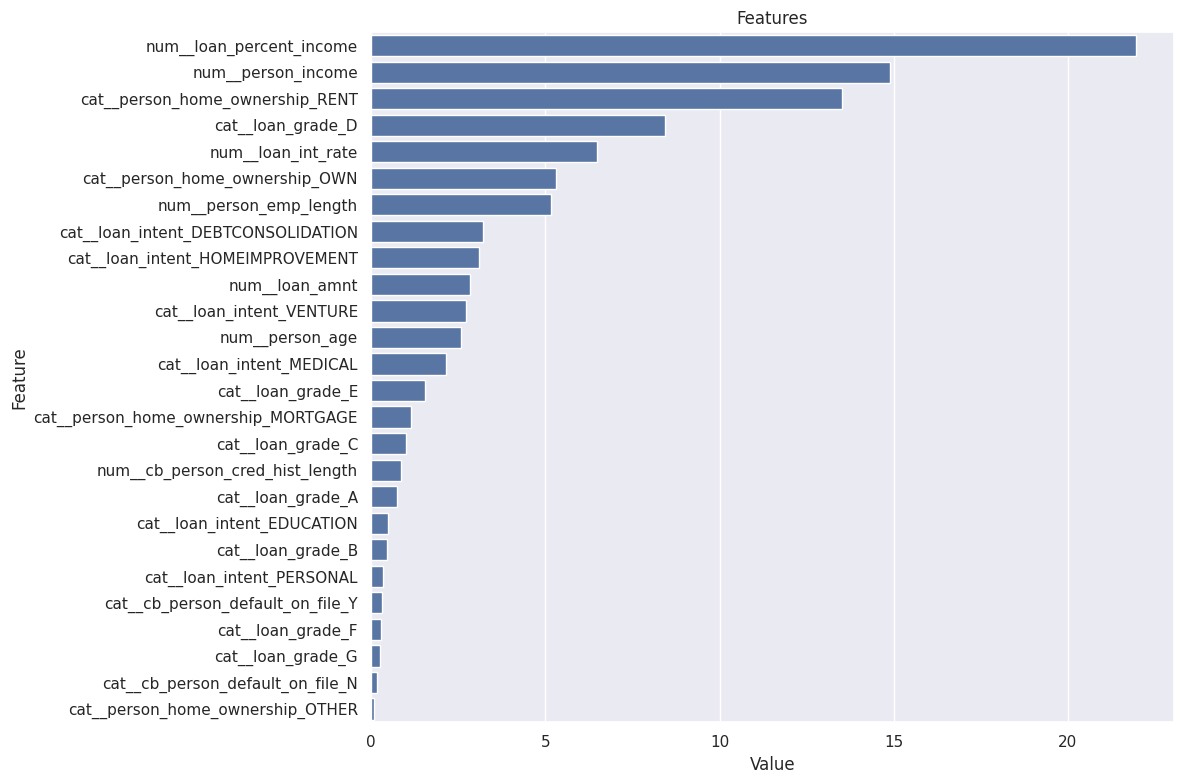

In [25]:
def plot_importance(model, features, num=len(X_train_processed), save=False):

    feature_imp = pd.DataFrame({"Value": model.feature_importances_, "Feature": features.columns})
    plt.figure(figsize=(12, 8))
    sns.set(font_scale=1)
    sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False)[0:num])
    plt.title("Features")
    plt.tight_layout()
    plt.show()
    if save:
        plt.savefig("importances.png")

model = CatBoostClassifier(silent=True)
model.fit(X_train_processed, y_train)

plot_importance(model, X_train_processed)